# ACT Demo: Verification with VNNLib

Complete verification workflow using ACT framework with VNNLib benchmarks:
1. **Model Loading**: Load VNNLib benchmark and synthesize models
2. **Verification**: IntervalTF (forward bounds) + DualTF (certified bounds)
3. **Analysis**: Spurious counterexample inference

In [1]:
# Setup and imports
import sys, os 
import io
from contextlib import redirect_stdout

f = io.StringIO()
# with redirect_stdout(f):
#     from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
#     from act.front_end.model_synthesis import synthesize_models_from_specs
act_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
sys.path.insert(0, act_root) if act_root not in sys.path else None

import logging
# Configure logging: suppress verbose INFO logs from vnnlib_loader
logging.getLogger('act.front_end.vnnlib_loader').setLevel(logging.ERROR)
import torch
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pathlib import Path
from collections import Counter

# Force reload modules
import importlib
modules_to_reload = [
    'act.front_end.model_synthesis',
    'act.front_end.vnnlib_loader.create_specs',
]
for mod_name in modules_to_reload:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
from act.front_end.model_synthesis import synthesize_models_from_specs
from act.pipeline.verification.torch2act import TorchToACT
from act.back_end.dual_tf import DualTF, compute_forward_bounds
from act.back_end.solver import DualSolver
from act.back_end.analyze import analyze, initialize_tf_mode
from act.back_end.core import Bounds, Fact, ConSet

# CIFAR-100 class names
CIFAR100_CLASSES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

print("Setup complete")

[ACT] Auto-detecting project root: ..
[WARN] Gurobi license not found: ../modules/gurobi/gurobi.lic
[INFO] Please place gurobi.lic in: ../modules/gurobi
Setup complete


## Step 1: Load VNNLib Benchmark and Synthesize Models

In [2]:
print("="*80)
print("LOADING CIFAR-100 VNNLIB BENCHMARK")
print("="*80)

creator = VNNLibSpecCreator(config_name="vnnlib_default")
spec_results = creator.create_specs_for_data_model_pairs(
    categories=["cifar100_2024"],
    max_instances=3,
    validate_shapes=True
)
print(f"Loaded {len(spec_results)} spec results\n")

print("Synthesizing wrapped models...")
wrapped_models = synthesize_models_from_specs(spec_results)
print(f"Synthesized {len(wrapped_models)} wrapped model(s) (specs get deduplicated by model)\n")

# The loader bundles all instances into ONE wrapped model with a batched
# INPUT_SPEC (shape [B, 3, 32, 32]) and batched labels. Unpack per instance.
wrapped_models_list = list(wrapped_models.values())
combo_ids = list(wrapped_models.keys())
assert len(wrapped_models_list) == 1, (
    f"Expected 1 wrapped model holding batched specs, got {len(wrapped_models_list)}"
)
wrapped_model = wrapped_models_list[0]
combo_id = combo_ids[0]

input_spec = wrapped_model.input_spec.spec
labels = wrapped_model.input_layer.labeled_input.label.flatten().long()
B = input_spec.lb.shape[0]
print(f"Batch size (instances to verify together): B={B}")

instance_info = []
for idx in range(B):
    lb_i = input_spec.lb[idx]
    ub_i = input_spec.ub[idx]
    epsilon = float((ub_i - lb_i).max())
    true_label_int = int(labels[idx].item())
    instance_info.append({
        "index": idx,
        "combo_id": combo_id,
        "true_label": true_label_int,
        "epsilon": epsilon,
        "lb": lb_i,
        "ub": ub_i,
    })
    print(f"  Instance {idx}: {CIFAR100_CLASSES[true_label_int]} (label={true_label_int}), eps={epsilon:.6f}")

print(f"\nReady for batched verification")


LOADING CIFAR-100 VNNLIB BENCHMARK
Loaded 3 spec results

Synthesizing wrapped models...

🧬 Synthesizing models from 3 spec result(s)...

🎉 Synthesis Complete:
   Total specs: 3
   Wrapped models: 1
Synthesized 1 wrapped model(s) (specs get deduplicated by model)

Batch size (instances to verify together): B=3
  Instance 0: worm (label=99), eps=0.030590
  Instance 1: sea (label=71), eps=0.030590
  Instance 2: castle (label=17), eps=0.030590

Ready for batched verification


## Step 2: Convert to ACT Net for Verification

In [3]:
print("="*80)
print("CONVERTING TO ACT NET (one net, shared across the B instances)")
print("="*80)

demo_idx = 0
info = instance_info[demo_idx]

# Batched verification variables (used by the DualTF cell)
input_lb_batched = input_spec.lb.flatten(start_dim=1)
input_ub_batched = input_spec.ub.flatten(start_dim=1)
y_true_batched = labels
B = input_lb_batched.shape[0]

# Single-instance demo variables (used by IntervalTF + forward-vs-backward cells)
demo_lb = input_spec.lb[demo_idx]
demo_ub = input_spec.ub[demo_idx]
true_label = int(labels[demo_idx].item())
epsilon = info["epsilon"]
input_tensor = wrapped_model.input_layer.labeled_input.tensor

print(f"Demo (single-instance) label: {CIFAR100_CLASSES[true_label]} (label={true_label}), eps={epsilon:.6f}")
print(f"Batched verification: B={B} instances, input_lb.shape={tuple(input_lb_batched.shape)}")

converter = TorchToACT(wrapped_model)
act_net = converter.run()

print(f"\nACT layers: {len(act_net.layers)}")
all_vars = [v for layer in act_net.layers for v in layer.out_vars]
total_vars = max(all_vars) + 1 if all_vars else 0
print(f"Variables: {total_vars}")

print(f"\nNetwork structure (first 5 and last 3 layers):")
for i, layer in enumerate(act_net.layers[:5]):
    print(f"  {i:2d}. {layer.kind:15s} | Out vars: {len(layer.out_vars):6d}")
print("  ...")
for i, layer in enumerate(act_net.layers[-3:], len(act_net.layers)-3):
    print(f"  {i:2d}. {layer.kind:15s} | Out vars: {len(layer.out_vars):6d}")


CONVERTING TO ACT NET (one net, shared across the B instances)
Demo (single-instance) label: worm (label=99), eps=0.030590
Batched verification: B=3 instances, input_lb.shape=(3, 3072)

ACT layers: 43
Variables: 214444

Network structure (first 5 and last 3 layers):
   0. INPUT           | Out vars:   9216
   1. INPUT_SPEC      | Out vars:   9216
   2. CONV2D          | Out vars:  14400
   3. RELU            | Out vars:  14400
   4. CONV2D          | Out vars:   8192
  ...
  40. RELU            | Out vars:    100
  41. DENSE           | Out vars:    100
  42. ASSERT          | Out vars:    100


## Step 3: IntervalTF - Layer-by-Layer Bounds Propagation

INTERVAL BOUNDS PROPAGATION (Layer-by-Layer)
Input bounds: lb=[-1.8974, 1.1985], ub=[-1.8824, 1.2278]

Running forward interval propagation using IntervalTF...
Computed bounds for 43 layers

Layer  Kind                Vars  Width(mean)   Width(max)
-------------------------------------------------------
0      INPUT               3072       0.0291       0.0306
1      INPUT_SPEC          3072       0.0291       0.0306
2      CONV2D             14400       0.0824       0.2984
3      RELU               14400       0.0199       0.2984
4      CONV2D              8192       0.1478       0.9274
5      RELU                8192       0.0148       0.7722
6      CONV2D              8192       0.3815       4.7535
7      CONV2D              8192       0.0436       0.5050
8      ADD                 8192       0.4251       4.8306
9      CONV2D              8192          nan          nan
...
38     FLATTEN             2048          nan          nan
39     DENSE                100          nan         

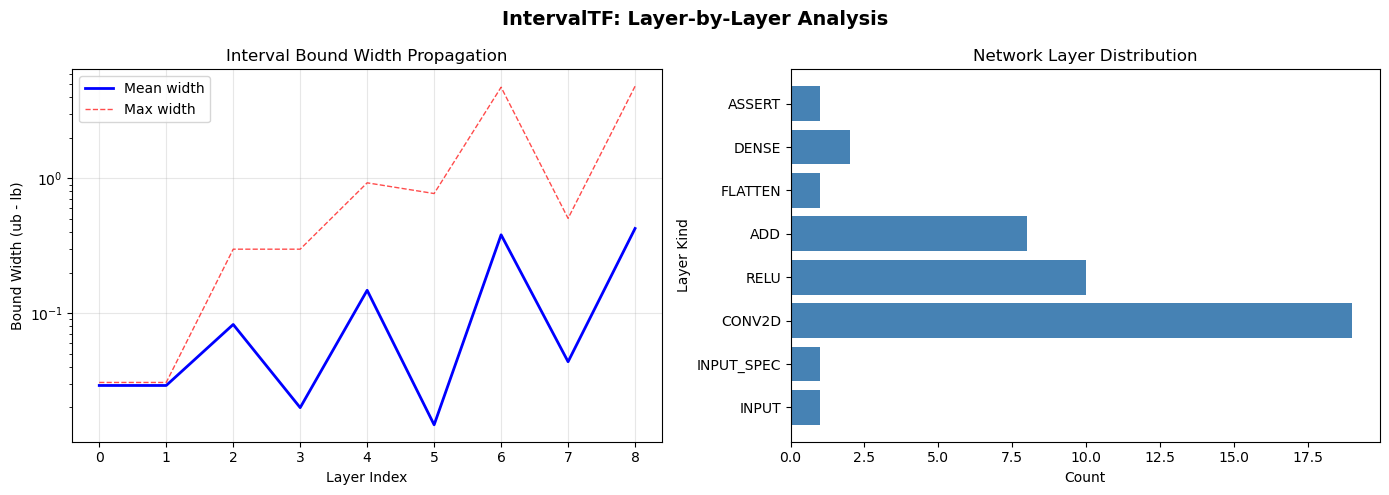


Key Observations:
  Input bound width (mean): 0.029053
  Output bound width (mean): nan
  Bound expansion ratio: nanx

Output layer bounds:
  Shape: torch.Size([100])
  lb range: [nan, nan]
  ub range: [nan, nan]


In [4]:
print("="*80)
print("INTERVAL BOUNDS PROPAGATION (Layer-by-Layer)")
print("="*80)

# Create input bounds from epsilon
if input_tensor.dim() == 4:
    input_flat = input_tensor.squeeze(0).flatten()
else:
    input_flat = input_tensor.flatten()

# Single-instance (demo_idx) for layer-by-layer IntervalTF demo;
# batched DualTF verification happens in the next section.
input_lb = demo_lb.flatten()
input_ub = demo_ub.flatten()

print(f"Input bounds: lb=[{input_lb.min():.4f}, {input_lb.max():.4f}], ub=[{input_ub.min():.4f}, {input_ub.max():.4f}]")

# Use IntervalTF via analyze() for proper bounds propagation
print("\nRunning forward interval propagation using IntervalTF...")
initialize_tf_mode("interval")  # Use IntervalTF

# Create entry fact with input bounds
entry_bounds = Bounds(lb=input_lb, ub=input_ub)
entry_fact = Fact(bounds=entry_bounds, cons=ConSet())

# Run analysis - returns (before, after, globalC)
entry_id = act_net.layers[0].id  # INPUT layer
before, after, globalC = analyze(act_net, entry_id, entry_fact)

# Convert after dict to bounds_dict format for compatibility with DualTF
bounds_dict = {lid: fact.bounds for lid, fact in after.items()}
print(f"Computed bounds for {len(bounds_dict)} layers")

# Collect layer statistics
layer_stats = []
for layer in act_net.layers:
    bounds = bounds_dict.get(layer.id)
    if bounds is not None:
        lb, ub = bounds.lb, bounds.ub
        width = (ub - lb)
        layer_stats.append({
            'id': layer.id,
            'kind': layer.kind,
            'num_vars': len(lb.flatten()),
            'width_mean': width.mean().item(),
            'width_max': width.max().item(),
            'lb_range': f"[{lb.min().item():.3f}, {lb.max().item():.3f}]",
            'ub_range': f"[{ub.min().item():.3f}, {ub.max().item():.3f}]",
        })

# Print table
print(f"\n{'Layer':<6} {'Kind':<15} {'Vars':>8} {'Width(mean)':>12} {'Width(max)':>12}")
print("-"*55)
for s in layer_stats[:10]:
    print(f"{s['id']:<6} {s['kind']:<15} {s['num_vars']:>8} {s['width_mean']:>12.4f} {s['width_max']:>12.4f}")
if len(layer_stats) > 15:
    print("...")
for s in layer_stats[-5:]:
    print(f"{s['id']:<6} {s['kind']:<15} {s['num_vars']:>8} {s['width_mean']:>12.4f} {s['width_max']:>12.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bound width evolution
layer_indices = range(len(layer_stats))
mean_widths = [s['width_mean'] for s in layer_stats]
max_widths = [s['width_max'] for s in layer_stats]

axes[0].plot(layer_indices, mean_widths, 'b-', label='Mean width', linewidth=2)
axes[0].plot(layer_indices, max_widths, 'r--', label='Max width', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Layer Index')
axes[0].set_ylabel('Bound Width (ub - lb)')
axes[0].set_title('Interval Bound Width Propagation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Layer kind distribution
kind_counts = Counter([s['kind'] for s in layer_stats])
kinds = list(kind_counts.keys())
counts = list(kind_counts.values())
axes[1].barh(kinds, counts, color='steelblue')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Layer Kind')
axes[1].set_title('Network Layer Distribution')

plt.suptitle('IntervalTF: Layer-by-Layer Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Key observations
print(f"\nKey Observations:")
print(f"  Input bound width (mean): {layer_stats[0]['width_mean']:.6f}")
print(f"  Output bound width (mean): {layer_stats[-1]['width_mean']:.6f}")
expansion_ratio = layer_stats[-1]['width_mean'] / (layer_stats[0]['width_mean'] + 1e-10)
print(f"  Bound expansion ratio: {expansion_ratio:.2f}x")

# Store output bounds for DualTF
output_layer = act_net.layers[-2]  # Before ASSERT
output_bounds = bounds_dict.get(output_layer.id)
if output_bounds:
    print(f"\nOutput layer bounds:")
    print(f"  Shape: {output_bounds.lb.shape}")
    print(f"  lb range: [{output_bounds.lb.min():.4f}, {output_bounds.lb.max():.4f}]")
    print(f"  ub range: [{output_bounds.ub.min():.4f}, {output_bounds.ub.max():.4f}]")


## Step 4: DualTF - Robust Classification Bound

In [5]:
print("="*80)
print(f"DUAL TF VERIFICATION — BATCHED (B={B} instances in a single pass)")
print("="*80)

# Step 1: compute forward bounds for all B instances in ONE batched call
print(f"\nComputing batched forward bounds (B={B})...")
dual_bounds_dict = compute_forward_bounds(act_net, input_lb_batched, input_ub_batched)
out_layer = act_net.layers[-2]
print(f"  Output layer {out_layer.id} ({out_layer.kind}): bounds shape = {tuple(dual_bounds_dict[out_layer.id].lb.shape)}")
print(f"  Bounds computed for {len(dual_bounds_dict)} layers")

dual_tf = DualTF()
dual_solver = DualSolver(dual_tf)
num_classes = 100

# Step 2: batched robust verification — one call returns per-instance margins
print(f"\nRunning batched robust verification (compute_robust_bound over {B} instances)...")
min_margin_b, certified_b = dual_solver.compute_robust_bound(
    act_net, dual_bounds_dict, y_true_batched, num_classes
)
print(f"  min_margin shape: {tuple(min_margin_b.shape)}")
print(f"  certified shape:  {tuple(certified_b.shape)}")

print(f"\nPer-instance results:")
print(f"  {'Idx':<4} {'True label':<22} {'MinMargin':>12}  Status")
print(f"  {'-'*4} {'-'*22} {'-'*12}  {'-'*14}")
for i in range(B):
    lbl = int(y_true_batched[i].item())
    mm = float(min_margin_b[i].item())
    cert = bool(certified_b[i].item())
    print(f"  {i:<4} {CIFAR100_CLASSES[lbl]:<22} {mm:>12.6f}  [{'CERTIFIED' if cert else 'NOT CERTIFIED'}]")

# Step 3: demonstrate batched custom-c margin — one compute_bound call, B results
#         Each row of c encodes instance b's (true_label=+1, worst_adv_class=-1) pair.
print(f"\nBatched custom-c margin demo:")

input_4d = wrapped_model.input_layer.labeled_input.tensor
if input_4d.dim() == 3:
    input_4d = input_4d.unsqueeze(0)
with torch.no_grad():
    orig_output = wrapped_model(input_4d)
    if isinstance(orig_output, dict):
        orig_output = orig_output["output"]

adv_classes = []
for i in range(B):
    scores = orig_output[i].detach().clone()
    scores[int(y_true_batched[i].item())] = float("-inf")
    adv_classes.append(int(scores.argmax().item()))

out_bounds = dual_bounds_dict[out_layer.id]
c_batched = torch.zeros(B, num_classes, dtype=out_bounds.lb.dtype, device=out_bounds.lb.device)
for i in range(B):
    c_batched[i, int(y_true_batched[i].item())] = 1.0
    c_batched[i, adv_classes[i]] = -1.0

print(f"  c_batched shape: {tuple(c_batched.shape)}  (one row per instance)")
margins_b = dual_solver.compute_bound(act_net, dual_bounds_dict, c_batched)
print(f"  One compute_bound call → margins shape: {tuple(margins_b.shape)}")

print(f"\n  {'Idx':<4} {'True':<18} {'Worst-adv':<18} {'Margin':>10}  Status")
print(f"  {'-'*4} {'-'*18} {'-'*18} {'-'*10}  {'-'*10}")
for i in range(B):
    tl = int(y_true_batched[i].item())
    ac = adv_classes[i]
    m = float(margins_b[i].item())
    status = "OK" if m > 0 else "VULN"
    print(f"  {i:<4} {CIFAR100_CLASSES[tl]:<18} {CIFAR100_CLASSES[ac]:<18} {m:>10.4f}  [{status}]")

# Single-instance summary views used by the legacy spurious-CE + summary cells.
min_margin = min_margin_b[demo_idx]
is_certified = bool(certified_b[demo_idx].item())


DUAL TF VERIFICATION — BATCHED (B=3 instances in a single pass)

Computing batched forward bounds (B=3)...
  Output layer 41 (DENSE): bounds shape = (3, 100)
  Bounds computed for 43 layers

Running batched robust verification (compute_robust_bound over 3 instances)...
  min_margin shape: (3,)
  certified shape:  (3,)

Per-instance results:
  Idx  True label                MinMargin  Status
  ---- ---------------------- ------------  --------------
  0    worm                      -0.608829  [NOT CERTIFIED]
  1    sea                       -3.581741  [NOT CERTIFIED]
  2    castle                    -0.656836  [NOT CERTIFIED]

Batched custom-c margin demo:
  c_batched shape: (3, 100)  (one row per instance)
  One compute_bound call → margins shape: (3,)

  Idx  True               Worst-adv              Margin  Status
  ---- ------------------ ------------------ ----------  ----------
  0    worm               lobster               -0.6088  [VULN]
  1    sea                dolphin       

## Step4b: Forward bound  v.s. Backward bound Margin Comparison

In [6]:
# ============================================================================
# Compare Forward Bound vs Backward (Dual) Bound — on demo_idx instance
# Build a single-instance demo view over the batched dual_bounds_dict; the
# downstream spurious-CE cell (13) reuses these demo_* variables too.
# ============================================================================
print("\n" + "="*80)
print(f"FORWARD vs BACKWARD BOUND COMPARISON — instance demo_idx={demo_idx}")
print("="*80)

demo_bounds_dict = {
    lid: Bounds(b.lb[demo_idx:demo_idx+1], b.ub[demo_idx:demo_idx+1])
    for lid, b in dual_bounds_dict.items()
}
dual_output_bounds = demo_bounds_dict[out_layer.id]
top10_classes = torch.topk(orig_output[demo_idx], k=10).indices.tolist()
orig_pred = int(orig_output[demo_idx].argmax().item())
orig_conf = float(torch.softmax(orig_output[demo_idx], dim=0)[orig_pred].item())

print(f"  True label: {true_label} ({CIFAR100_CLASSES[true_label]})")
print(f"  Model prediction: {orig_pred} ({CIFAR100_CLASSES[orig_pred]}), conf={orig_conf:.3f}")
print()
print(f"  {'Class':<6} {'Name':<15} {'Forward':>12} {'Backward':>12} {'Improvement':>12} {'Status'}")
print(f"  {'-'*6} {'-'*15} {'-'*12} {'-'*12} {'-'*12} {'-'*8}")

margins = []
for target_class in top10_classes:
    if target_class == true_label:
        continue

    forward_margin = (
        dual_output_bounds.lb[0, true_label]
        - dual_output_bounds.ub[0, target_class]
    ).item()

    c = torch.zeros(num_classes, dtype=dual_output_bounds.lb.dtype, device=dual_output_bounds.lb.device)
    c[true_label] = 1.0
    c[target_class] = -1.0
    backward_margin = dual_solver.compute_bound(act_net, demo_bounds_dict, c.unsqueeze(0)).squeeze(0).item()
    margins.append((target_class, backward_margin))

    improvement = backward_margin - forward_margin
    status = "TIGHTER" if improvement > 1e-6 else "-"
    print(f"  {target_class:<6} {CIFAR100_CLASSES[target_class]:<15} {forward_margin:>12.4f} {backward_margin:>12.4f} {improvement:>+12.4f} [{status}]")

print()
print("Note: forward = interval (lb[true] - ub[target]); backward = dual/Lagrangian (tighter).")

margins_sorted = sorted(margins, key=lambda x: x[1]) if margins else []
weakest_class = margins_sorted[0][0] if margins_sorted else -1
weakest_margin = margins_sorted[0][1] if margins_sorted else float("inf")



FORWARD vs BACKWARD BOUND COMPARISON — instance demo_idx=0
  True label: 99 (worm)
  Model prediction: 99 (worm), conf=0.507

  Class  Name                 Forward     Backward  Improvement Status
  ------ --------------- ------------ ------------ ------------ --------
  45     lobster             -17.7393      -0.6088     +17.1305 [TIGHTER]
  78     snake               -18.0131       0.5338     +18.5469 [TIGHTER]
  26     crab                -17.4735       0.5119     +17.9854 [TIGHTER]
  10     bowl                -15.9082       0.9605     +16.8687 [TIGHTER]
  50     mouse               -16.0138       1.2724     +17.2863 [TIGHTER]
  74     shrew               -16.0093       1.0761     +17.0853 [TIGHTER]
  22     clock               -15.5239       2.0510     +17.5749 [TIGHTER]
  14     butterfly           -15.8348       1.7944     +17.6292 [TIGHTER]
  64     possum              -15.5181       1.5630     +17.0811 [TIGHTER]

Note: forward = interval (lb[true] - ub[target]); backward = d

## Step 5: Spurious Counterexample (false alarm) Analysis

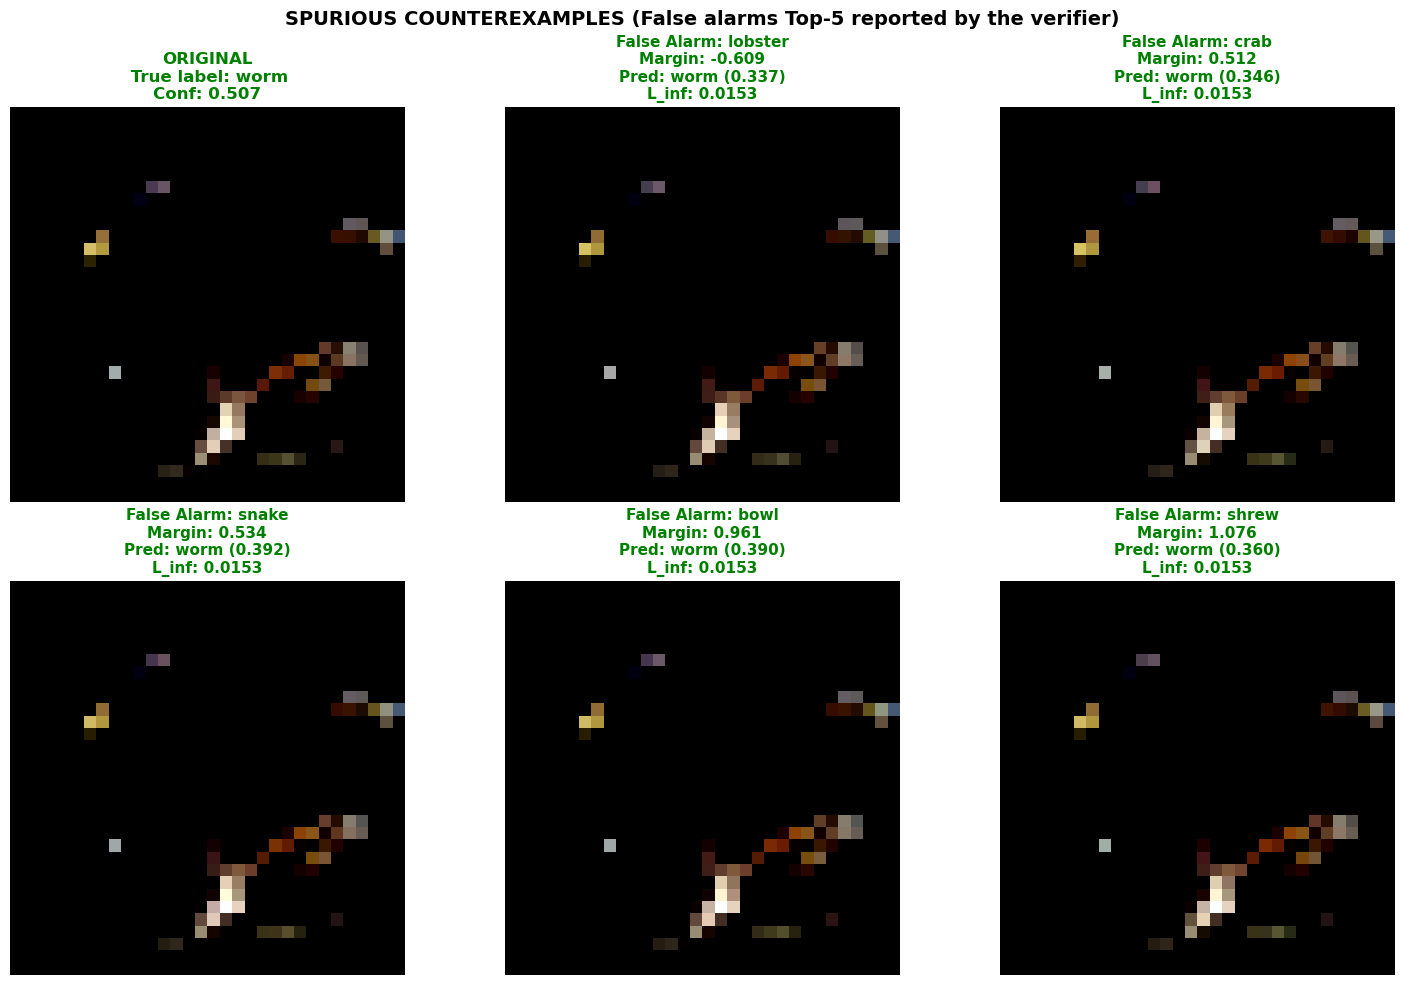


 AdvClass | ClassName            |     Margin | FA_pred | PredName             |     Conf |    L_inf |  Within_eps
-------------------------------------------------------------------------------------------------------------------
       45 | lobster              |    -0.6088 |      99 | worm                 |   0.3368 |   0.0153 |        True
       26 | crab                 |     0.5119 |      99 | worm                 |   0.3457 |   0.0153 |        True
       78 | snake                |     0.5338 |      99 | worm                 |   0.3917 |   0.0153 |        True
       10 | bowl                 |     0.9605 |      99 | worm                 |   0.3896 |   0.0153 |        True
       74 | shrew                |     1.0761 |      99 | worm                 |   0.3604 |   0.0153 |        True

Most vulnerable (min margin) in Top 5: 45 (lobster)
Margin: -0.608829

RESULT: model maintains correct classification
  This is a false alarm (greedy boundary selection)
  Real adversarial may

In [7]:


# Select the top 5 adversarial classes by margin (lowest 5 non-true_label in top10)
sce_infos = []
adv_class_candidates = []

# 1. Gather (adv_class, margin) for all top10 classes (excluding true_label)
# Use DualTF's bounds (demo_bounds_dict) for analysis
for adv_class in top10_classes:
    if adv_class == true_label:
        continue
    c = torch.zeros(num_classes, dtype=dual_output_bounds.lb.dtype, device=dual_output_bounds.lb.device)
    c[true_label] = 1.0
    c[adv_class] = -1.0
    margin = dual_solver.compute_bound(act_net, demo_bounds_dict, c.unsqueeze(0)).squeeze(0)
    if isinstance(margin, torch.Tensor):
        margin = margin.item()
    adv_class_candidates.append((adv_class, margin))

# 2. Sort by margin, pick top 5 most vulnerable (lowest margins)
topk = 5
adv_class_sorted = sorted(adv_class_candidates, key=lambda x: x[1])[:topk]

# 3. For each of the top 5, generate input info
for adv_class, margin in adv_class_sorted:
    c = torch.zeros(num_classes, dtype=dual_output_bounds.lb.dtype, device=dual_output_bounds.lb.device)
    c[true_label] = 1.0
    c[adv_class] = -1.0
    margin_b, sce_b = dual_solver.compute_bound(act_net, demo_bounds_dict, c.unsqueeze(0), return_sce=True)
    margin_val = margin_b.squeeze(0).item() if isinstance(margin_b, torch.Tensor) else float(margin_b)
    sce_raw = sce_b[0] if (sce_b is not None and sce_b.dim() >= 1) else sce_b
    expected_size = 3 * 32 * 32  # image size for CIFAR

    # Recover image
    if sce_raw.numel() != expected_size:
        input_layer = act_net.layers[1]
        sce_input_bounds = demo_bounds_dict.get(input_layer.id)
        if sce_input_bounds is not None:
            _flat = sce_input_bounds.lb.clone().flatten()
            _per = 3 * 32 * 32
            sce_image = _flat[:_per].reshape(1, 3, 32, 32) if _flat.numel() >= _per else _flat.reshape(1, 3, 32, 32)
        else:
            sce_image = input_tensor.clone()
    else:
        sce_image = sce_raw.reshape(1, 3, 32, 32)

    # Inference
    pytorch_model = wrapped_model.model
    pytorch_model.eval()
    with torch.no_grad():
        sce_output = pytorch_model(sce_image)
        sce_pred = sce_output.argmax(dim=1).item()
        sce_probs = torch.softmax(sce_output[0], dim=0)
        sce_conf = sce_probs[sce_pred].item()
        sce_target_conf = sce_probs[adv_class].item()

    # Perturbation w.r.t. original input
    if input_tensor.dim() == 4:
        orig_tensor = input_tensor.squeeze(0)
    else:
        orig_tensor = input_tensor
    _ot_flat = orig_tensor.flatten()
    _per = 3 * 32 * 32
    _ot_img = _ot_flat[:_per].reshape(3, 32, 32) if _ot_flat.numel() >= _per else _ot_flat.reshape(3, 32, 32)
    diff = sce_image.squeeze() - _ot_img.to(sce_image.device)
    l_inf = diff.abs().max().item()
    
    sce_infos.append({
        "adv_class": adv_class,
        "adv_class_name": CIFAR100_CLASSES[adv_class],
        "margin": margin_val,
        "sce_pred": sce_pred,
        "sce_pred_name": CIFAR100_CLASSES[sce_pred],
        "sce_conf": sce_conf,
        "sce_target_conf": sce_target_conf,
        "l_inf": l_inf,
        "sce_image": sce_image
    })

# 4. Visualization: 3x2 grid, first is ORIGINAL and five false alarms
import math
nrow, ncol = 2, 3
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*5, nrow*5))

# Plot original image in [0,0]
if input_tensor.dim() == 4:
    orig_tensor = input_tensor.squeeze(0)
else:
    orig_tensor = input_tensor
_ot_flat = orig_tensor.flatten(); _per = 3 * 32 * 32
orig_img = (_ot_flat[:_per].reshape(3, 32, 32) if _ot_flat.numel() >= _per else _ot_flat.reshape(3, 32, 32)).permute(1, 2, 0)
orig_img_np = np.clip(orig_img.cpu().numpy(), 0, 1)
axes[0,0].imshow(orig_img_np, interpolation='nearest')
axes[0,0].set_title(f'ORIGINAL\n True label: {CIFAR100_CLASSES[true_label]}\nConf: {orig_conf:.3f}', 
                    fontsize=12, color='green', fontweight='bold')
axes[0,0].axis('off')

for idx, info in enumerate(sce_infos):
    pos = idx + 1
    row = pos // ncol
    col = pos % ncol
    ax = axes[row, col]
    sce_img = info['sce_image'].squeeze().permute(1, 2, 0)
    sce_img_np = np.clip(sce_img.cpu().numpy(), 0, 1)
    ax.imshow(sce_img_np, interpolation='nearest')
    color = 'red' if info['sce_pred'] != true_label else 'green'
    ax.set_title(
        f"False Alarm: {info['adv_class_name']}\n"
        f"Margin: {info['margin']:.3f}\n"
        f"Pred: {info['sce_pred_name']} ({info['sce_conf']:.3f})\n"
        f"L_inf: {info['l_inf']:.4f}",
        fontsize=11, color=color, fontweight='bold'
    )
    ax.axis('off')

# Hide empty axes if any
for i in range(len(sce_infos) + 1, nrow*ncol):
    row = i // ncol
    col = i % ncol
    axes[row, col].axis('off')

plt.suptitle('SPURIOUS COUNTEREXAMPLES (False alarms Top-5 reported by the verifier)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Table summary
header = (
    f"\n{'AdvClass':>9s} | {'ClassName':<20s} | {'Margin':>10s} | {'FA_pred':>7s} "
    f"| {'PredName':<20s} | {'Conf':>8s} | {'L_inf':>8s} | {'Within_eps':>11s}"
)
print(header)
print("-" * len(header))
for info in sce_infos:
    within_eps = info["l_inf"] <= epsilon
    print(
        f"{info['adv_class']:9d} | "
        f"{info['adv_class_name']:<20s} | "
        f"{info['margin']:10.4f} | "
        f"{info['sce_pred']:7d} | "
        f"{info['sce_pred_name']:<20s} | "
        f"{info['sce_conf']:8.4f} | "
        f"{info['l_inf']:8.4f} | "
        f"{str(within_eps):>11s}"
    )

# Also, summary for the one with lowest margin among the selected
min_info = min(sce_infos, key=lambda x: x["margin"])
print("\n" + "="*62)
print(f"Most vulnerable (min margin) in Top 5: {min_info['adv_class']} ({min_info['adv_class_name']})")
print(f"Margin: {min_info['margin']:.6f}")
print("="*62)

if min_info['sce_pred'] != true_label:
    if min_info['sce_pred'] == min_info['adv_class']:
        print(f"\nRESULT: True counterexample causes misclassification to TARGET class!")
    else:
        print(f"\nRESULT: True counterexample causes misclassification to different class: {min_info['sce_pred_name']}")
else:
    print("\nRESULT: model maintains correct classification")
    print("  This is a false alarm (greedy boundary selection)")
    print("  Real adversarial may exist but requires more sophisticated search")


## Step 6: Results Summary

In [8]:
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*80)

print(f"\n[Model Information]")
print(f"  Benchmark: cifar100_2024")
print(f"  Instances tested: {len(instance_info)}")
print(f"  Demo instance: {CIFAR100_CLASSES[true_label]} (label={true_label})")
print(f"  Epsilon: {epsilon:.6f}")

print(f"\n[DualTF Verification]")
print(f"  Min margin: {min_margin.item():.6f}")
print(f"  Certified: {is_certified}")
print(f"  Most vulnerable class: {weakest_class} ({CIFAR100_CLASSES[weakest_class]})")


print(f"  false alarm prediction: {CIFAR100_CLASSES[sce_pred]}")
print(f"  Misclassification: {sce_pred != true_label}")
print(f"  Perturbation L_inf: {l_inf:.6f}")

print(f"\n[Conclusion]")
if is_certified:
    print(f"  Model is CERTIFIED ROBUST for this instance")
else:
    print(f"  Model is NOT CERTIFIED ROBUST")
    if sce_pred != true_label:
        print(f"  false alarm analysis suggests potential vulnerability to class {CIFAR100_CLASSES[sce_pred]}")
    else:
        print(f"  Further analysis recommended")

print("\n" + "="*80)




COMPREHENSIVE RESULTS SUMMARY

[Model Information]
  Benchmark: cifar100_2024
  Instances tested: 3
  Demo instance: worm (label=99)
  Epsilon: 0.030590

[DualTF Verification]
  Min margin: -0.608829
  Certified: False
  Most vulnerable class: 45 (lobster)
  false alarm prediction: worm
  Misclassification: False
  Perturbation L_inf: 0.015295

[Conclusion]
  Model is NOT CERTIFIED ROBUST
  Further analysis recommended



## Step 7: ACASXu Verification (DualTF)

Same dual-mode API (`compute_forward_bounds` + `DualSolver.compute_bound`) applied to
ACASXu networks from `data/vnnlib/acasxu_2023/`. Properties use `UNSAFE_LINEAR` output
specs (possibly multi-disjunct): the instance is **unsafe if `c_i^T y ≤ d_i` for any
disjunct `i`**. To certify SAFETY we prove
**`compute_bound(c_i) > d_i` for every disjunct** — i.e., the certified dual lower
bound of `c_i · y` strictly exceeds the unsafe threshold for all constraints.


In [9]:
from act.front_end.specs import OutKind

print("="*80)
print("ACASXu Verification (DualTF)")
print("="*80)

# Load 2 ACASXu instances via the same VNNLibSpecCreator already in use above.
acasxu_spec_results = creator.create_specs_for_data_model_pairs(
    categories=["acasxu_2023"],
    max_instances=2,
    validate_shapes=True,
)
acasxu_wrapped = synthesize_models_from_specs(acasxu_spec_results)
print(f"Loaded {len(acasxu_wrapped)} ACASXu instance(s)\n")

# Reuse dual_tf / dual_solver from Step 4.
for combo_id, wm in acasxu_wrapped.items():
    print("-"*80)
    print(f"Instance: {combo_id}")

    # Convert the wrapped ONNX model to an ACT Net. ACASXu models contain an
    # input-normalization subtract (``x - mean``) that TorchToACT's call_function
    # dispatcher does not yet handle (no ``sub`` entry in ``_handle_call_function``).
    # Skip such instances with a clear diagnostic so the notebook still runs cleanly.
    try:
        acasxu_net = TorchToACT(wm).run()
    except NotImplementedError as e:
        print(f"  [SKIP] TorchToACT gap: {str(e).splitlines()[0]}")
        print(f"  (Hint: extend act/pipeline/verification/torch2act.py"
              " _handle_call_function() with a 'sub' handler.)")
        continue

    in_spec = wm.input_spec.spec
    out_spec = wm.output_spec.spec

    in_lb = in_spec.lb.flatten(start_dim=1)
    in_ub = in_spec.ub.flatten(start_dim=1)
    B_i = in_lb.shape[0]
    print(f"  Input bounds: {tuple(in_lb.shape)}, output spec kind: {out_spec.kind}")

    # Dual forward bounds (same API as Step 4).
    dbounds = compute_forward_bounds(acasxu_net, in_lb, in_ub)
    acasxu_out_layer = acasxu_net.layers[-2]
    out_lb_vec = dbounds[acasxu_out_layer.id].lb.squeeze().tolist()
    out_ub_vec = dbounds[acasxu_out_layer.id].ub.squeeze().tolist()
    print(f"  Output ({acasxu_out_layer.kind}) dual bounds:")
    print(f"    lb: {[f'{v:+.3f}' for v in out_lb_vec]}")
    print(f"    ub: {[f'{v:+.3f}' for v in out_ub_vec]}")

    if out_spec.kind != OutKind.UNSAFE_LINEAR:
        print(f"  (Skipping verdict: spec kind {out_spec.kind} not handled here)")
        continue

    c_all = out_spec.c
    d_all = out_spec.d
    if c_all.dim() == 1:
        c_all = c_all.unsqueeze(0)
    if d_all.dim() == 0:
        d_all = d_all.unsqueeze(0)
    K = c_all.shape[0]

    # UNSAFE_LINEAR semantics: unsafe if c_k^T y <= d_k for ANY disjunct k.
    # To certify SAFETY we need lower_bound(c_k^T y) > d_k for EVERY disjunct.
    print(f"  Checking {K} disjunct(s); SAFE requires lower_bound(c_k^T y) > d_k for ALL k")
    ref_lb = dbounds[acasxu_out_layer.id].lb
    all_safe = True
    for k in range(K):
        c_k = c_all[k].to(device=ref_lb.device, dtype=ref_lb.dtype)
        c_k = c_k.unsqueeze(0).expand(B_i, -1).contiguous()
        lb_cTy = dual_solver.compute_bound(acasxu_net, dbounds, c_k).squeeze()
        d_k = float(d_all[k].item())
        mval = float(lb_cTy.item()) if lb_cTy.dim() == 0 else float(lb_cTy[0].item())
        disjunct_safe = mval > d_k
        tag = "SAFE" if disjunct_safe else "NOT CERTIFIED"
        print(f"    disjunct {k}: lb(c^T y) = {mval:+.4f}, d = {d_k:+.4f}  [{tag}]")
        all_safe = all_safe and disjunct_safe

    verdict = "CERTIFIED SAFE" if all_safe else "UNCERTIFIED"
    print(f"  ==> Property verdict: {verdict}")


ACASXu Verification (DualTF)

🧬 Synthesizing models from 2 spec result(s)...

🎉 Synthesis Complete:
   Total specs: 2
   Wrapped models: 2
Loaded 2 ACASXu instance(s)

--------------------------------------------------------------------------------
Instance: ('acasxu_2023', 'ACASXU_run2a_1_2_batch_2000_prop_1', 'BOX', 'UNSAFE_LINEAR')
  Input bounds: (1, 5), output spec kind: UNSAFE_LINEAR
  Output (DENSE) dual bounds:
    lb: ['-1274.770', '-1721.204', '-1572.445', '-2546.040', '-2216.276']
    ub: ['+3823.164', '+4429.173', '+4566.919', '+4798.453', '+4689.382']
  Checking 1 disjunct(s); SAFE requires lower_bound(c_k^T y) > d_k for ALL k
    disjunct 0: lb(c^T y) = -1852.1913, d = -3.9911  [NOT CERTIFIED]
  ==> Property verdict: UNCERTIFIED
--------------------------------------------------------------------------------
Instance: ('acasxu_2023', 'ACASXU_run2a_1_3_batch_2000_prop_1', 'BOX', 'UNSAFE_LINEAR')
  Input bounds: (1, 5), output spec kind: UNSAFE_LINEAR
  Output (DENSE) dual 